# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Brain Tumer Classification using ViT finetuning</h2>

### Setup

This notebook fine-tunes a pretrained **ViT (Vision Transformer)** on brain MRI scans to classify tumor type. Run the cells top to bottom on a **GPU-enabled** Kaggle session with **Internet turned on** (required to download the ViT checkpoint).

In [1]:
import random
import numpy as np
import torch
from IPython.display import display, Markdown

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device: cuda


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Load and Explore the Data</h2>

In [2]:
TRAIN_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
TEST_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model and Preprocessing</h2>

In [3]:
from transformers import ViTForImageClassification, ViTImageProcessor
CHECKPOINT = 'google/vit-base-patch16-224'
NUM_CLASSES = 4
image_processor = ViTImageProcessor.from_pretrained(CHECKPOINT)
model = ViTForImageClassification.from_pretrained(
CHECKPOINT, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [4]:
import torch
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

class BrainTumorDataset(Dataset):
    def __init__(self, root, processor):
        self.data = datasets.ImageFolder(root)
        self.processor = processor
        self.classes = self.data.classes
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image, label = self.data[idx]
        inputs = self.processor(images=image.convert('RGB'), return_tensors='pt')
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),'labels': torch.tensor(label)
            }
train_dataset = BrainTumorDataset(TRAIN_DIR, image_processor)
test_dataset = BrainTumorDataset(TEST_DIR, image_processor)
CLASS_NAMES = train_dataset.classes
train_loader = DataLoader(
            train_dataset, batch_size=32, shuffle=True, num_workers=2
        )
test_loader = DataLoader(
            test_dataset, batch_size=32, shuffle=False, num_workers=2
        )
print('Classes:', CLASS_NAMES)
print(f'Train samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train samples: 5600
Test samples: 1600


In [5]:
# Quick sanity check on a single sample
sample = train_dataset[0]
print('pixel_values shape:', sample['pixel_values'].shape)
print('label index       :', sample['labels'].item())
print('label name        :', CLASS_NAMES[sample['labels'].item()])

pixel_values shape: torch.Size([3, 224, 224])
label index       : 0
label name        : glioma


In [6]:
train_dataset[0]

{'pixel_values': tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]]]),
 'labels': tensor(0)}

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Class Distribution</h2>


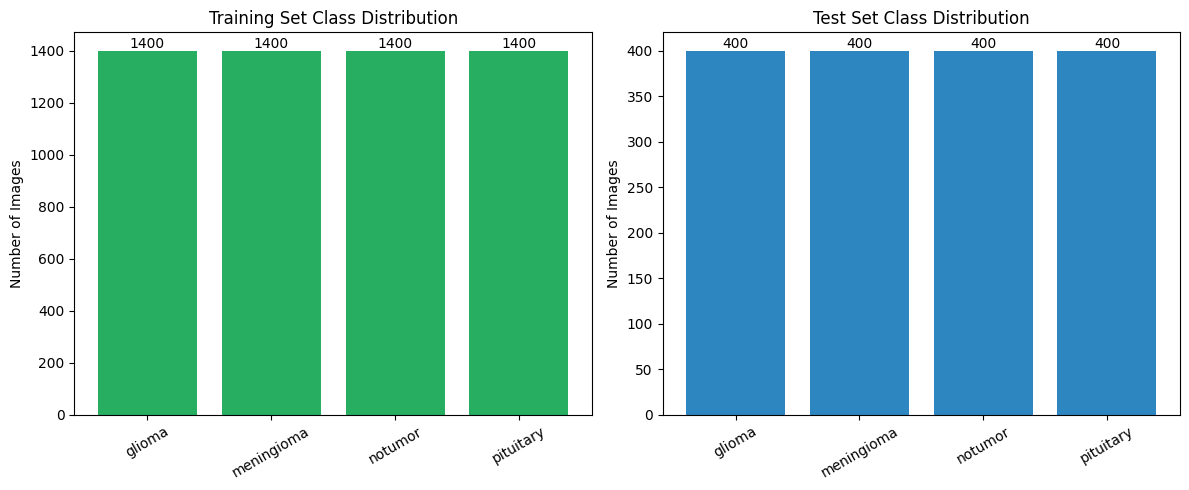

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

train_counts = pd.Series(train_dataset.data.targets).value_counts().sort_index()
test_counts = pd.Series(test_dataset.data.targets).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(CLASS_NAMES, train_counts.values, color='#27AE60')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

axes[1].bar(CLASS_NAMES, test_counts.values, color='#2E86C1')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Sample Training Images</h2>


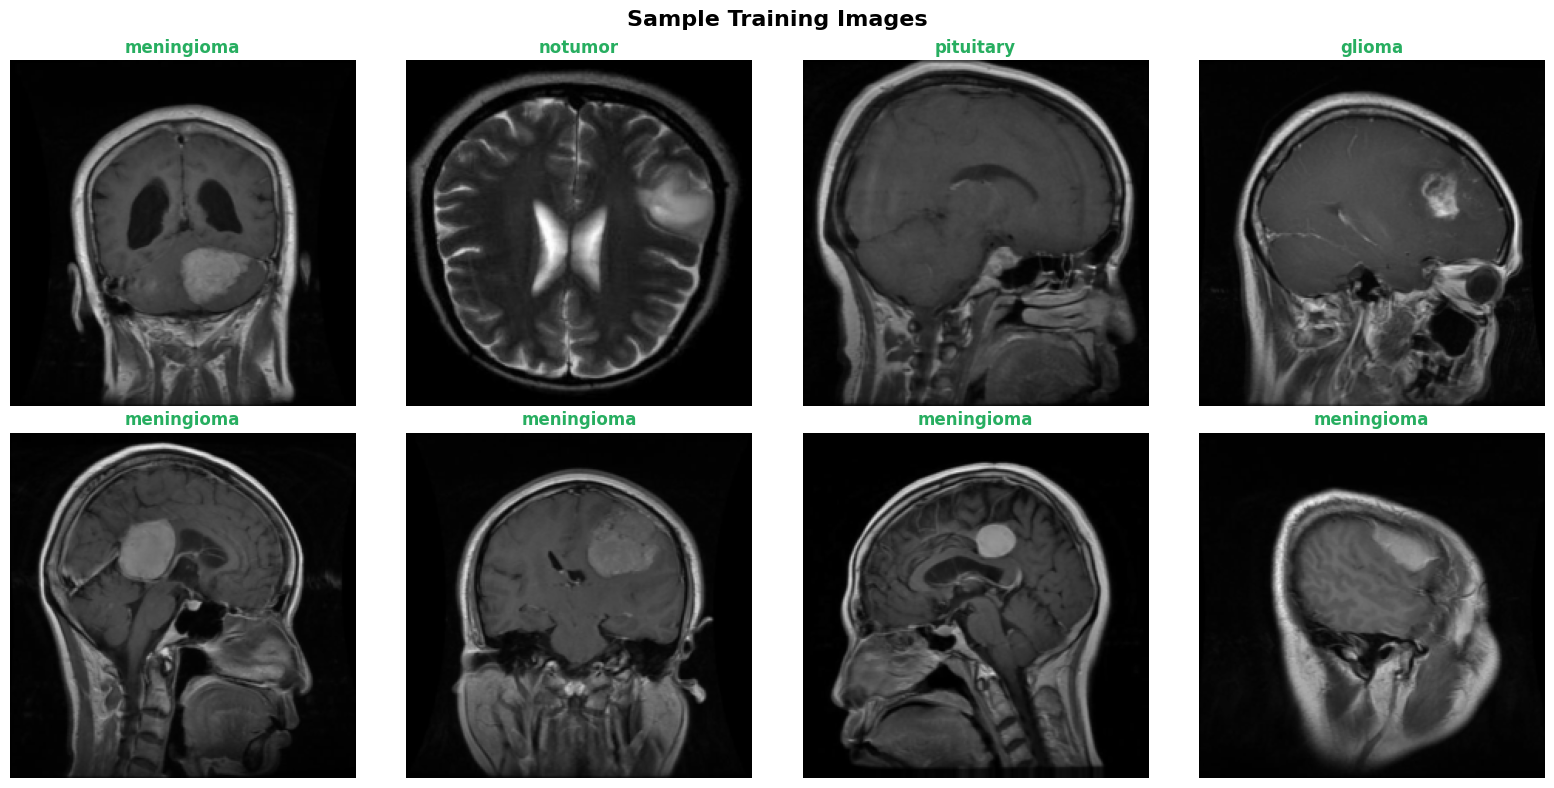

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch_images(loader, class_names, num_images=8):
    # Get one batch
    batch = next(iter(loader))
    pixel_values = batch['pixel_values']
    labels = batch['labels']

    num_images = min(num_images, len(pixel_values))
    cols = 4
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(num_images):
        img = pixel_values[i].permute(1, 2, 0).numpy()  # C,H,W -> H,W,C

        # Undo normalization using the processor's actual mean/std
        mean = np.array(image_processor.image_mean)
        std = np.array(image_processor.image_std)
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(class_names[labels[i].item()], fontsize=12, color='#27AE60', fontweight='bold')
        plt.axis('off')

    plt.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_batch_images(train_loader, CLASS_NAMES, num_images=8)



# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Training Loop</h2>

In [9]:
from transformers import get_linear_schedule_with_warmup
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 6
LR = 2e-5

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    # ---------------- Training ----------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        running_loss += loss.item() * batch['labels'].size(0)
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == batch['labels']).sum().item()
        total += batch['labels'].size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---------------- Validation ----------------
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            running_loss += loss.item() * batch['labels'].size(0)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total += batch['labels'].size(0)

    test_loss = running_loss / total
    test_acc = correct / total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Test Acc: {test_acc:.4f}")

Epoch 1/6 | Train Loss: 0.5796 Train Acc: 0.7900 | Test Loss: 0.3045 Test Acc: 0.9019
Epoch 2/6 | Train Loss: 0.0770 Train Acc: 0.9780 | Test Loss: 0.2093 Test Acc: 0.9444
Epoch 3/6 | Train Loss: 0.0151 Train Acc: 0.9973 | Test Loss: 0.2411 Test Acc: 0.9475
Epoch 4/6 | Train Loss: 0.0056 Train Acc: 0.9996 | Test Loss: 0.2653 Test Acc: 0.9444
Epoch 5/6 | Train Loss: 0.0032 Train Acc: 1.0000 | Test Loss: 0.2749 Test Acc: 0.9437
Epoch 6/6 | Train Loss: 0.0025 Train Acc: 1.0000 | Test Loss: 0.2739 Test Acc: 0.9444


# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Training Curves</h2>


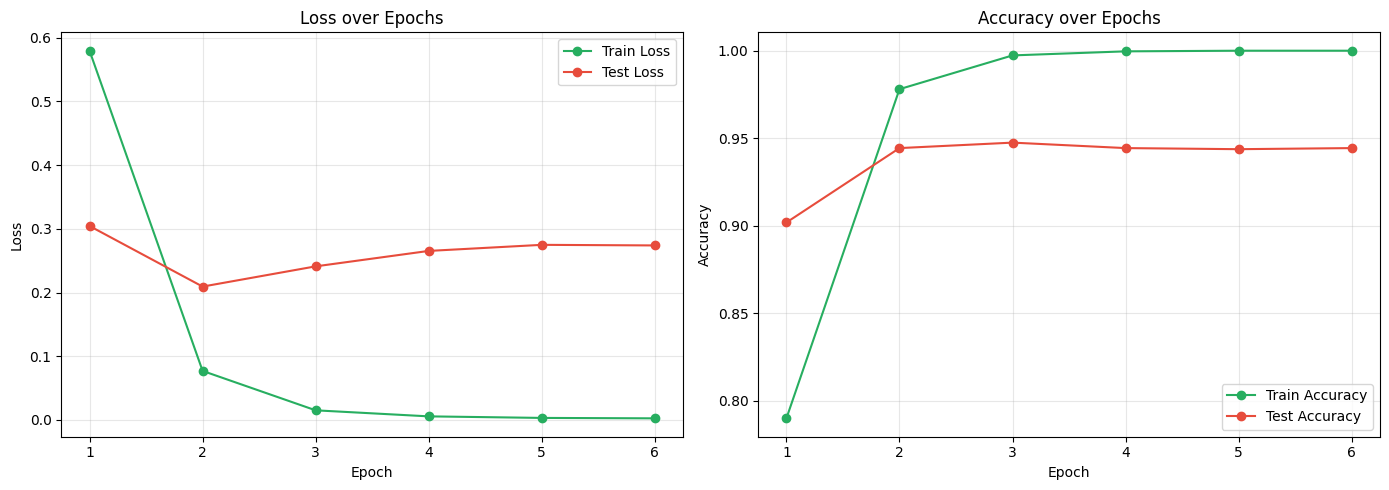

In [10]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train Loss', color='#27AE60')
axes[0].plot(epochs_range, history['test_loss'], marker='o', label='Test Loss', color='#E74C3C')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Train Accuracy', color='#27AE60')
axes[1].plot(epochs_range, history['test_acc'], marker='o', label='Test Accuracy', color='#E74C3C')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Evaluation on Test Set</h2>


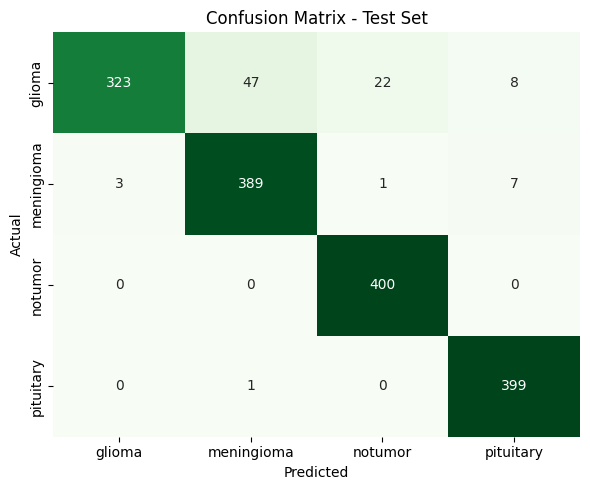

FINAL TEST ACCURACY: 0.9444 (94.44%)

Classification Report:

              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.89      0.97      0.93       400
     notumor       0.95      1.00      0.97       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

final_test_acc = (all_preds == all_labels).mean()
print('=' * 45)
print(f'FINAL TEST ACCURACY: {final_test_acc:.4f} ({final_test_acc * 100:.2f}%)')
print('=' * 45)
print('\nClassification Report:\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# <h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>Save Artifacts</h2>

In [12]:
import os, json, torch
os.makedirs('artifacts', exist_ok=True)
torch.save(model.state_dict(), 'artifacts/vit_brain_tumor.pt')

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model Saved</span>"))

class_names = train_dataset.classes
with open('artifacts/class_names.json', 'w') as f:
    json.dump(class_names, f)
    
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Class Name Saved</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Model Saved</span>

### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Class Name Saved</span>